In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers
from matplotlib import pyplot
from sklearn.metrics import accuracy_score ,confusion_matrix ,classification_report
from sklearn import metrics  

In [2]:
data= pd.read_csv("binary_dataset_balanced_200.csv")
data.head()

,age,income,hours_study,experience_years,outcome
0,63,48697,6.04,16,1
1,20,32232,6.83,16,1
2,46,39571,5.85,5,0
3,52,53459,4.71,15,1
4,56,57914,1.83,8,0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               200 non-null    int64  
 1   income            200 non-null    int64  
 2   hours_study       200 non-null    float64
 3   experience_years  200 non-null    int64  
 4   outcome           200 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 7.9 KB


In [4]:
x=data.drop("outcome",axis=1)
y=data["outcome"]

In [5]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=10)

scaler = StandardScaler()
xtrain = scaler.fit_transform(xtrain)
xtest = scaler.transform(xtest)


In [6]:
model=keras.Sequential([
    layers.Dense(124,activation="relu",input_shape=(4,)),
    layers.Dense(64,activation="relu"),
    layers.Dense(32,activation="relu"),          
    layers.Dense(16,activation="relu"),        
    layers.Dense(8,activation="relu"),
    layers.Dense(1,activation="sigmoid")
])

C:\Users\USER\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [8]:
history=model.fit(
    xtrain,
    ytrain,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss",patience=5)]
)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 240ms/step - accuracy: 0.5781 - loss: 0.6886 - val_accuracy: 0.6250 - val_loss: 0.6764
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.7266 - loss: 0.6689 - val_accuracy: 0.6875 - val_loss: 0.6634
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.7734 - loss: 0.6511 - val_accuracy: 0.6875 - val_loss: 0.6450
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7812 - loss: 0.6292 - val_accuracy: 0.6875 - val_loss: 0.6204
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7891 - loss: 0.6029 - val_accuracy: 0.7500 - val_loss: 0.5884
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7656 - loss: 0.5698 - val_accuracy: 0.7500 - val_loss: 0.5545
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7812 - loss: 0.5352 - val_accuracy: 0.6875 - val_loss: 0.5241
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7656 - loss: 0.5022 - val_accuracy: 0.6875 - val_loss

In [9]:
history.history

{'accuracy': [0.578125,
  0.7265625,
  0.7734375,
  0.78125,
  0.7890625,
  0.765625,
  0.78125,
  0.765625,
  0.7578125,
  0.7578125,
  0.7578125,
  0.765625,
  0.7734375,
  0.796875,
  0.7890625],
 'loss': [0.6886362433433533,
  0.6689490079879761,
  0.6511204838752747,
  0.6292299032211304,
  0.6029036045074463,
  0.5697746872901917,
  0.535234808921814,
  0.5022486448287964,
  0.4724869132041931,
  0.4587053060531616,
  0.4463874399662018,
  0.44066914916038513,
  0.43147414922714233,
  0.422616571187973,
  0.41686683893203735],
 'val_accuracy': [0.625,
  0.6875,
  0.6875,
  0.6875,
  0.75,
  0.75,
  0.6875,
  0.6875,
  0.6875,
  0.6875,
  0.71875,
  0.71875,
  0.71875,
  0.71875,
  0.71875],
 'val_loss': [0.6763767004013062,
  0.6634224653244019,
  0.6449583768844604,
  0.6204456686973572,
  0.5884268283843994,
  0.5544857978820801,
  0.5241326689720154,
  0.5037409663200378,
  0.4996945261955261,
  0.4985157251358032,
  0.5023691654205322,
  0.502953827381134,
  0.503414392471313

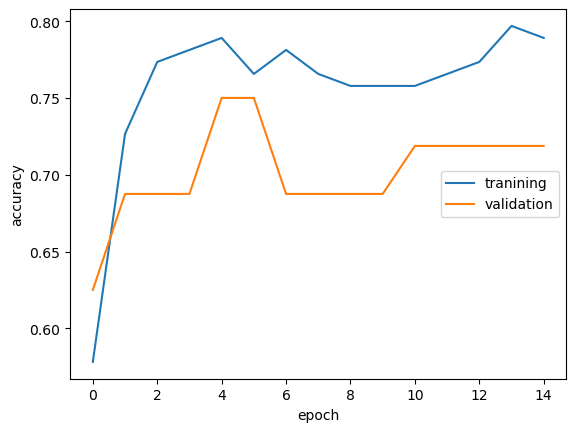

In [10]:
pyplot.plot(history.history["accuracy"],label="tranining")
pyplot.plot(history.history["val_accuracy"],label="validation")
pyplot.xlabel("epoch")
pyplot.ylabel("accuracy")
pyplot.legend(loc='center right')
pyplot.show()

In [11]:
jj=model.evaluate(xtrain,ytrain)
jj

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7812 - loss: 0.4293


[0.42926591634750366, 0.78125]

In [12]:
model.evaluate(xtest,ytest)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.7500 - loss: 0.5233 


[0.5233349800109863, 0.75]

In [13]:
yprob=model.predict(xtest)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step


In [14]:
ypred=(yprob>0.5).astype(int)

In [15]:
acc=accuracy_score(ytest,ypred)
acc

0.75

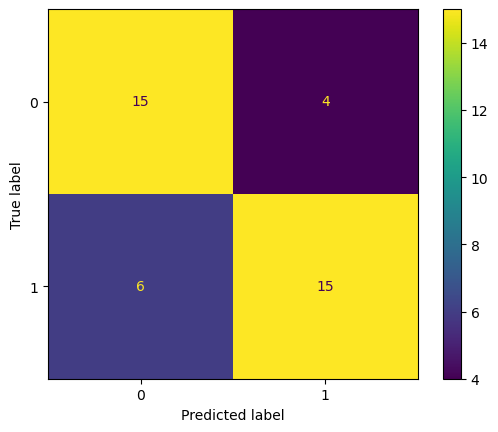

In [16]:
k=confusion_matrix(ytest,ypred)
##
kk=metrics.ConfusionMatrixDisplay(k)
kk.plot()
pyplot.show()

In [17]:
kk=classification_report(ytest,ypred,output_dict=True)
report=pd.DataFrame(kk)
report

,0,1,accuracy,macro avg,weighted avg
precision,0.714286,0.789474,0.75,0.75188,0.753759
recall,0.789474,0.714286,0.75,0.75188,0.750000
f1-score,0.750000,0.750000,0.75,0.75000,0.750000
support,19.000000,21.000000,0.75,40.00000,40.000000
